# Master Results Notebook for Paper Production

This notebook serves as the primary driver for generating the final, publication-quality figures and tables for the paper. It leverages the consolidated logic in `src/glass/` to ensure zero data loss and reproducible results.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

# --- Labelled / unlabelled UVJ region toggle ------------------------------
# Set to False and re-run this notebook to regenerate every UVJ figure with
# the Quiescent/Star-forming/Dusty text labels turned off. Filenames are the
# same either way, so paper.tex's \includegraphics targets never need
# updating -- whichever variant this notebook most recently produced is
# what's on disk and in the paper. The wedge boundaries themselves are
# unaffected; only the in-panel text labels are toggled. (ugr/IRAC diagrams
# don't have this concept and are unaffected by this flag.)
SHOW_REGION_LABELS = False

def plot_uvj(*args, **kwargs):
    kwargs.setdefault('show_region_labels', SHOW_REGION_LABELS)
    return visualization.plot_uvj_diagram(*args, **kwargs)

def save_uvj_fig(fig, path):
    """Saves fig to `path`; filename is unaffected by SHOW_REGION_LABELS."""
    fig.savefig(path, dpi=300, bbox_inches='tight')

## 1. Load Configurations and Base Models

We start by loading the necessary filters (UVJ, ugr, IRAC) and the base Type 1 and Type 2 AGN SKIRTOR models using parameters defined in the project's modelling methodology.

In [2]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = config.SKIRTOR_DIR
brown_dir = config.GALSEDATLAS_DIR

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate Colours

We will iterate over the alpha values, calculate composite SEDs for all templates and both AGN types, and compute their colours. For `ugr` and `IRAC` diagrams, specific artificial redshifting is applied to reflect survey selections.

In [3]:
results = []
alphas = config.ALPHA_VALUES

# Target redshifts for artificial redshifting
z_ugr = 3.0 # Within the U-dropout target range of 2.6 < z < 3.6
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}")
    
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            
            # Calculate UVJ (restframe)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            
            # Calculate ugr (redshifted to z=3.0)
            ug, gr = photometry.calculate_ugr_colours(comp_sed, filters['u'], filters['g'], filters['r'], redshift=z_ugr)
            
            # Calculate IRAC (restframe)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'U-V': uv,
                'V-J': vj,
                'u-g': ug,
                'g-r': gr,
                'f5836': f5836,
                'f8045': f8045
            })

df_results = pd.DataFrame(results)
print("Processed all composite combinations.")

Processing template 1/129: ARP_118
Processing template 2/129: ARP_256_N
Processing template 3/129: ARP_256_S
Processing template 4/129: CGCG_049_057
Processing template 5/129: CGCG_436_030
Processing template 6/129: CGCG_453_062
Processing template 7/129: HARO_06
Processing template 8/129: IC_0691
Processing template 9/129: IC_0860
Processing template 10/129: IC_0883
Processing template 11/129: IC_4051
Processing template 12/129: IC_4553
Processing template 13/129: IC_5298


Processing template 14/129: II_ZW_096
Processing template 15/129: III_ZW_035
Processing template 16/129: IRAS_08572+3915
Processing template 17/129: IRAS_17208_0014
Processing template 18/129: MRK_0331
Processing template 19/129: MRK_0475
Processing template 20/129: MRK_0930
Processing template 21/129: MRK_1450
Processing template 22/129: MRK_1490
Processing template 23/129: MRK_33
Processing template 24/129: NGC_0337
Processing template 25/129: NGC_0474


Processing template 26/129: NGC_0520
Processing template 27/129: NGC_0584
Processing template 28/129: NGC_0628
Processing template 29/129: NGC_0660
Processing template 30/129: NGC_0695
Processing template 31/129: NGC_0750
Processing template 32/129: NGC_0855
Processing template 33/129: NGC_1068
Processing template 34/129: NGC_1144
Processing template 35/129: NGC_1275
Processing template 36/129: NGC_1614
Processing template 37/129: NGC_2388
Processing template 38/129: NGC_2403


Processing template 39/129: NGC_2537
Processing template 40/129: NGC_2623
Processing template 41/129: NGC_2798
Processing template 42/129: NGC_3049
Processing template 43/129: NGC_3079
Processing template 44/129: NGC_3190
Processing template 45/129: NGC_3198
Processing template 46/129: NGC_3265
Processing template 47/129: NGC_3310
Processing template 48/129: NGC_3351
Processing template 49/129: NGC_3379
Processing template 50/129: NGC_3521
Processing template 51/129: NGC_3627


Processing template 52/129: NGC_3690
Processing template 53/129: NGC_3773
Processing template 54/129: NGC_3870
Processing template 55/129: NGC_3938
Processing template 56/129: NGC_4088
Processing template 57/129: NGC_4125
Processing template 58/129: NGC_4138
Processing template 59/129: NGC_4168
Processing template 60/129: NGC_4194
Processing template 61/129: NGC_4254
Processing template 62/129: NGC_4321
Processing template 63/129: NGC_4365
Processing template 64/129: NGC_4385


...

Processing template 77/129: NGC_4594
Processing template 78/129: NGC_4621
Processing template 79/129: NGC_4625
Processing template 80/129: NGC_4631
Processing template 81/129: NGC_4660
Processing template 82/129: NGC_4670
Processing template 83/129: NGC_4676_A
Processing template 84/129: NGC_4725
Processing template 85/129: NGC_4826
Processing template 86/129: NGC_4860
Processing template 87/129: NGC_4889
Processing template 88/129: NGC_4926
Processing template 89/129: NGC_5033


Processing template 90/129: NGC_5055
Processing template 91/129: NGC_5104
Processing template 92/129: NGC_5194
Processing template 93/129: NGC_5195
Processing template 94/129: NGC_5256
Processing template 95/129: NGC_5257
Processing template 96/129: NGC_5258
Processing template 97/129: NGC_5653
Processing template 98/129: NGC_5713
Processing template 99/129: NGC_5866
Processing template 100/129: NGC_5953
Processing template 101/129: NGC_5992
Processing template 102/129: NGC_6052


Processing template 103/129: NGC_6090
Processing template 104/129: NGC_6240
Processing template 105/129: NGC_7331
Processing template 106/129: NGC_7585
Processing template 107/129: NGC_7591
Processing template 108/129: NGC_7592
Processing template 109/129: NGC_7673
Processing template 110/129: NGC_7674
Processing template 111/129: NGC_7679
Processing template 112/129: NGC_7714
Processing template 113/129: NGC_7771
Processing template 114/129: UGC_04881
Processing template 115/129: UGC_05101


Processing template 116/129: UGC_06665
Processing template 117/129: UGC_06850
Processing template 118/129: UGC_08335_NW
Processing template 119/129: UGC_08335_SE
Processing template 120/129: UGC_08696
Processing template 121/129: UGC_09618_N
Processing template 122/129: UGC_09618_S
Processing template 123/129: UGC_09618
Processing template 124/129: UGC_12150
Processing template 125/129: UGCA_166
Processing template 126/129: UGCA_208
Processing template 127/129: UGCA_219
Processing template 128/129: UGCA_410


Processing template 129/129: UM_461
Processed all composite combinations.


## 3. Colour Evolution Evolution Plots

These plots show how individual galaxies move through colour-colour space as the AGN contribution ($\alpha$) increases from 0 to 1.

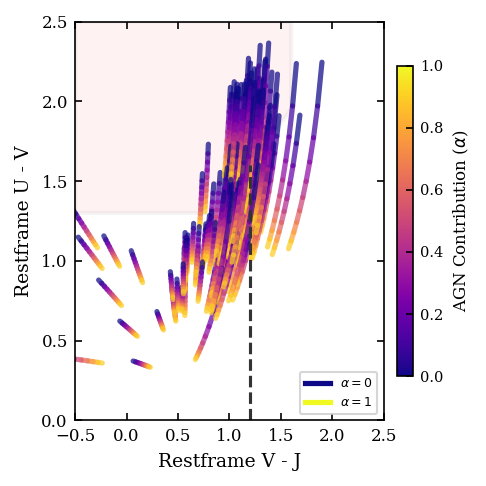

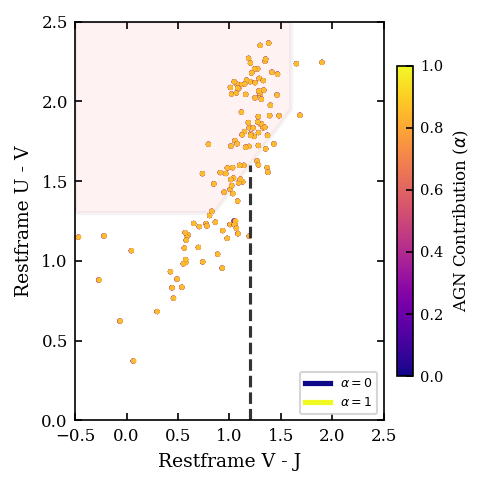

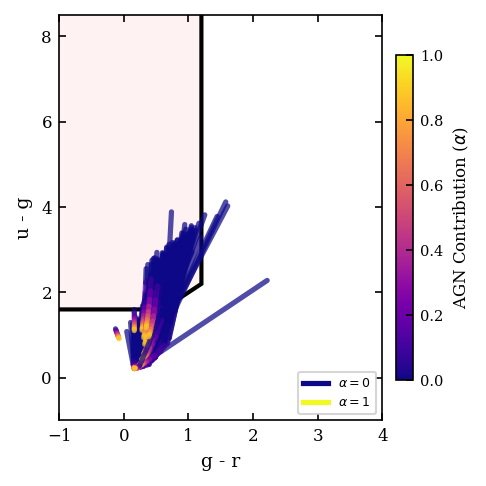

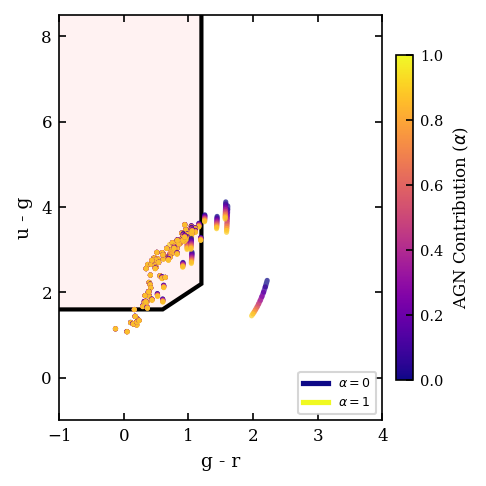

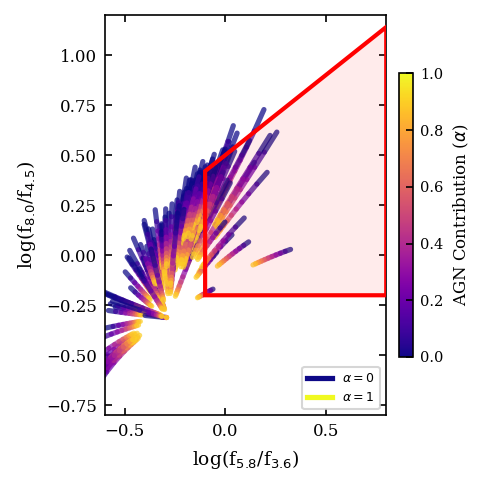

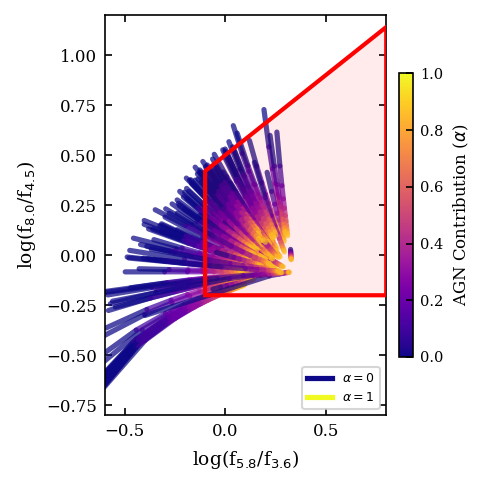

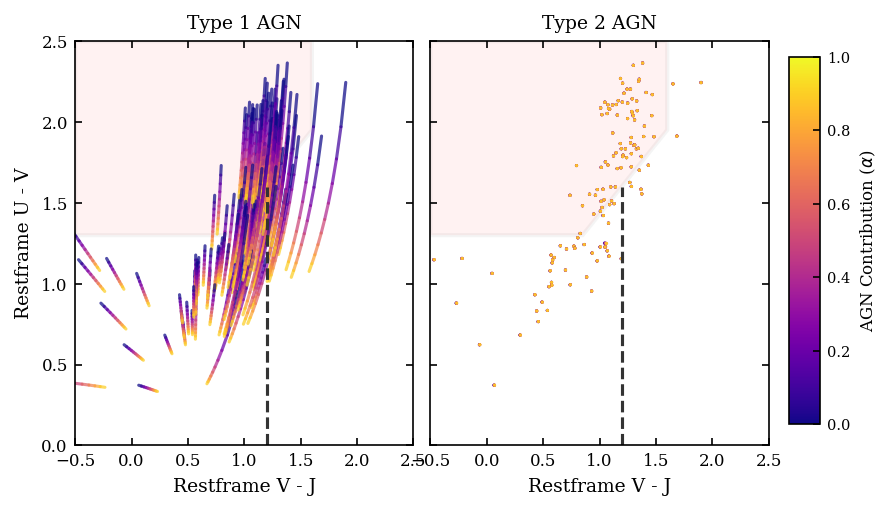

In [4]:
def plot_evolution_tracks(df, agn_type, x_col, y_col, plot_func, title, output_name):
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    subset = df[df['AGN_Type'] == agn_type]

    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=0, vmax=1)

    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs = temp_df[x_col].values
        ys = temp_df[y_col].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2],
                    color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=2.5, alpha=0.72, solid_capstyle='round')

    plot_func([], [], ax=ax, title=title)

    custom_lines = [
        Line2D([0], [0], color=cmap(0.0), lw=2.5, label=r'$\alpha=0$'),
        Line2D([0], [0], color=cmap(1.0), lw=2.5, label=r'$\alpha=1$'),
    ]
    ax.legend(handles=custom_lines, loc='lower right', fontsize=6)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    save_uvj_fig(fig, os.path.join(config.PROCESSED_DATA_DIR, output_name))
    return fig, ax

plot_evolution_tracks(df_results, 'Type1', 'V-J', 'U-V', plot_uvj,
                      '', 'Paper_UVJ_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'V-J', 'U-V', plot_uvj,
                      '', 'Paper_UVJ_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'g-r', 'u-g', visualization.plot_ugr_diagram,
                      '', 'Paper_ugr_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'g-r', 'u-g', visualization.plot_ugr_diagram,
                      '', 'Paper_ugr_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'f5836', 'f8045', visualization.plot_irac_diagram,
                      '', 'Paper_IRAC_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'f5836', 'f8045', visualization.plot_irac_diagram,
                      '', 'Paper_IRAC_Evolution_Type2.pdf')

# --- Combined UVJ evolution: Type 1 left, Type 2 right, shared y-axis ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=visualization.PASA_WIDE, sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, agn_type in [(ax1, 'Type1'), (ax2, 'Type2')]:
    subset = df_results[df_results['AGN_Type'] == agn_type]
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs, ys = temp_df['V-J'].values, temp_df['U-V'].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2], color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=1.5, alpha=0.72, solid_capstyle='round')
    panel_title = 'Type 1 AGN' if agn_type == 'Type1' else 'Type 2 AGN'
    plot_uvj([], [], ax=ax, title=panel_title)

ax2.set_ylabel('')

fig.subplots_adjust(wspace=0.05, right=0.80)
cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

save_uvj_fig(fig, os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Evolution_Combined.pdf'))
plt.show()

## 3b. SWIRE Template Evolution (Fig 3)

Generating initial composite modelling using the SWIRE template library.

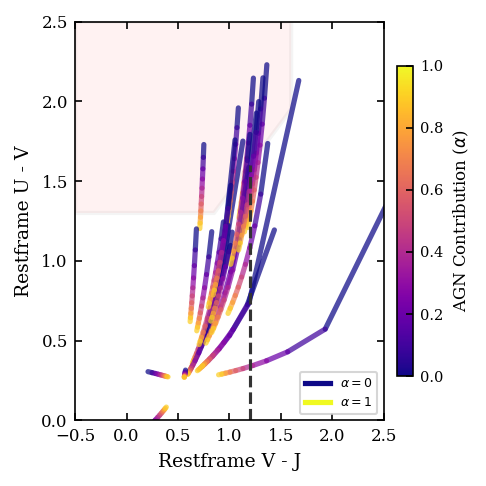

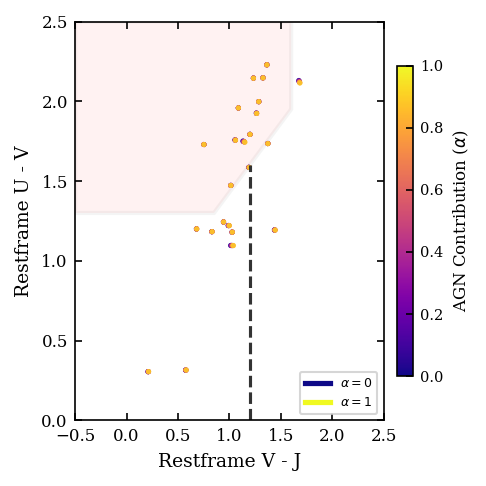

In [5]:
# Load SWIRE Templates
swire_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'SWIRE')
swire_templates, swire_names = data_io.read_swire_templates(swire_dir)

swire_results = []

for t_idx, gal_sed in enumerate(swire_templates):
    gal_name = swire_names[t_idx]
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            swire_results.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha': alpha, 'U-V': uv, 'V-J': vj})

df_swire_results = pd.DataFrame(swire_results)

plot_evolution_tracks(df_swire_results, 'Type1', 'V-J', 'U-V', plot_uvj, '', 'SWIREType1AGNUVJ.pdf')
plot_evolution_tracks(df_swire_results, 'Type2', 'V-J', 'U-V', plot_uvj, '', 'SWIREType2AGNUVJ.pdf')
plt.show()

## 4. Selection Completeness Analysis

Evaluating how well the standard selection wedges (UVJ, ugr dropout, Lacy IRAC) identify their targets as AGN contamination increases.

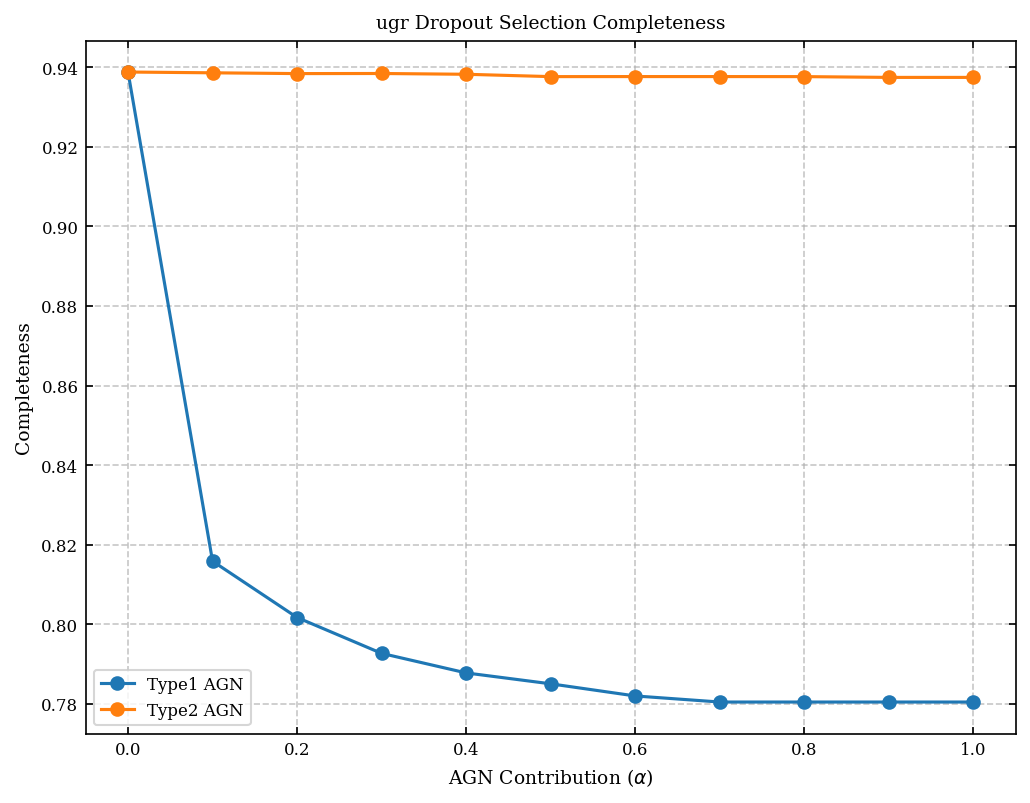

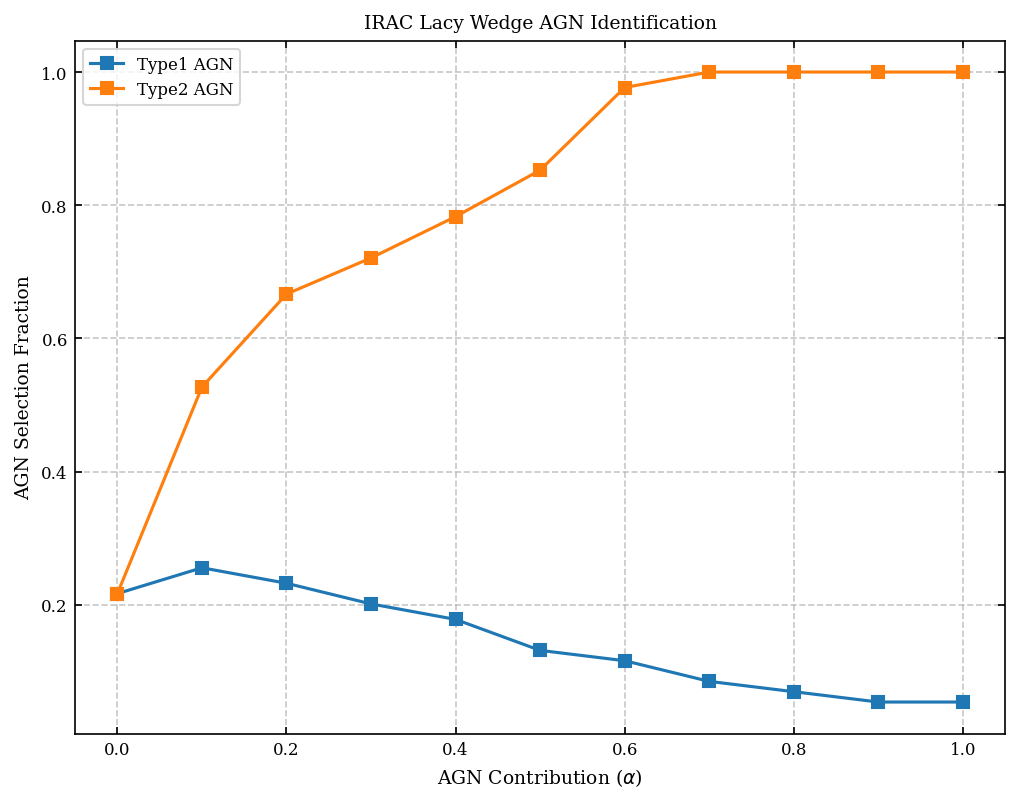

In [6]:
# 1. ugr Dropout Completeness (from redshift grid data)
grid_file = os.path.join(config.PROCESSED_DATA_DIR, 'ugr_completeness_grid.csv')
if os.path.exists(grid_file):
    df_grid = pd.read_csv(grid_file)
    df_comp_ugr = analysis.calculate_completeness_from_df(df_grid)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    for agn_type in df_comp_ugr['AGN_Type'].unique():
        subset = df_comp_ugr[df_comp_ugr['AGN_Type'] == agn_type]
        ax.plot(subset['Alpha'], subset['Completeness'], marker='o', label=f'{agn_type} AGN')
        
    ax.set_xlabel(r'AGN Contribution ($\alpha$)')
    ax.set_ylabel('Completeness')
    ax.set_title('ugr Dropout Selection Completeness')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_ugr_Completeness.pdf'), bbox_inches='tight')
    plt.show()

# 2. IRAC Lacy Wedge Completeness (calculated from df_results)
def calculate_irac_completeness(df):
    res = []
    for agn_type in df['AGN_Type'].unique():
        subset = df[df['AGN_Type'] == agn_type]
        for alpha in subset['Alpha'].unique():
            alpha_df = subset[subset['Alpha'] == alpha]
            in_wedge = analysis.is_in_lacy_wedge(alpha_df['f5836'], alpha_df['f8045'])
            # For IRAC, completeness is fraction identified as AGN
            completeness = np.sum(in_wedge) / len(alpha_df)
            res.append({'AGN_Type': agn_type, 'Alpha': alpha, 'Completeness': completeness})
    return pd.DataFrame(res)

df_comp_irac = calculate_irac_completeness(df_results)

fig, ax = plt.subplots(figsize=(8, 6))
for agn_type in df_comp_irac['AGN_Type'].unique():
    subset = df_comp_irac[df_comp_irac['AGN_Type'] == agn_type]
    ax.plot(subset['Alpha'], subset['Completeness'], marker='s', label=f'{agn_type} AGN')
    
ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('AGN Selection Fraction')
ax.set_title('IRAC Lacy Wedge AGN Identification')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_IRAC_Completeness.pdf'), bbox_inches='tight')
plt.show()

## 5. Statistical Tables (LaTeX Exports)

Exporting the final results to LaTeX for inclusion in the paper.

In [7]:
def calculate_uvj_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        
        vj_alpha = alpha_df['V-J'].values
        uv_alpha = alpha_df['U-V'].values
        vj_init = initial_df['V-J'].values
        uv_init = initial_df['U-V'].values
        
        mean_offset = analysis.calculate_mean_vector_offset(vj_alpha, uv_alpha, vj_init, uv_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_uvj_offsets(df_results, 'Type1')
off2 = calculate_uvj_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution ($\\alpha$)': [f"{int(a*100)}\\%" for a in alphas],
    'Type 1 Offset (dex)': off1['Mean_Offset'].round(3),
    'Type 2 Offset (dex)': off2['Mean_Offset'].round(3)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset for Type 1 and Type 2 AGN composites in the UVJ diagram.", label="tab:UVJ_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

print("Exported UVJ Vector Offset table.")

,AGN Contribution ($\\alpha$),Type 1 Offset (dex),Type 2 Offset (dex)
0,0\%,0.000,0.000
1,10\%,0.094,0.000
2,20\%,0.171,0.000
3,30\%,0.238,0.001
4,40\%,0.296,0.001
5,50\%,0.347,0.001
6,60\%,0.394,0.001
7,70\%,0.436,0.002
8,80\%,0.474,0.002
9,90\%,0.509,0.002


Exported UVJ Vector Offset table.


## 6. UVJ Population Fraction Analysis

This section analyzes how AGN contamination causes galaxies to migrate between the Star-forming, Quiescent, and Dusty regions of the UVJ diagram.

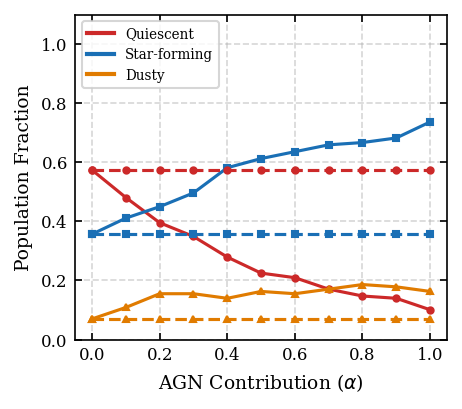

In [8]:
def calculate_uvj_fractions(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    alphas_sorted = sorted(subset['Alpha'].unique())
    q_fracs, sf_fracs, d_fracs = [], [], []
    for alpha in alphas_sorted:
        alpha_df = subset[subset['Alpha'] == alpha]
        classifications = analysis.classify_uvj(alpha_df['V-J'], alpha_df['U-V'])
        q, sf, d = analysis.calculate_population_fractions(classifications)
        q_fracs.append(q)
        sf_fracs.append(sf)
        d_fracs.append(d)
    return alphas_sorted, q_fracs, sf_fracs, d_fracs

fig, ax = plt.subplots(figsize=(3.15, 2.8))

pop_colors = {'Quiescent': '#CC2929', 'Star-forming': '#1A6FB5', 'Dusty': '#E07B00'}

for agn_type, ls in [('Type1', '-'), ('Type2', '--')]:
    alphas_sorted, q_fracs, sf_fracs, d_fracs = calculate_uvj_fractions(df_results, agn_type)
    type_label = 'Type 1' if agn_type == 'Type1' else 'Type 2'
    ax.plot(alphas_sorted, q_fracs,  color=pop_colors['Quiescent'],    linestyle=ls, marker='o', markersize=3, label=f'Quiescent ({type_label})')
    ax.plot(alphas_sorted, sf_fracs, color=pop_colors['Star-forming'], linestyle=ls, marker='s', markersize=3, label=f'Star-forming ({type_label})')
    ax.plot(alphas_sorted, d_fracs,  color=pop_colors['Dusty'],        linestyle=ls, marker='^', markersize=3, label=f'Dusty ({type_label})')

ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('Population Fraction')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim([0, 1.1])

# Compact legend: colour = population. Solid = Type 1, dashed = Type 2
# (line style distinction is explained in the figure caption, not the legend).
color_handles = [
    Line2D([0],[0], color=pop_colors['Quiescent'],    lw=2, label='Quiescent'),
    Line2D([0],[0], color=pop_colors['Star-forming'], lw=2, label='Star-forming'),
    Line2D([0],[0], color=pop_colors['Dusty'],        lw=2, label='Dusty'),
]
ax.legend(handles=color_handles, fontsize=6.5, loc='upper left')

plt.tight_layout()
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Fractions_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Composite SED Progression (Fig 6)

Recreating Figure 6: 1D SED progression for representative Star-forming, Quiescent, and Dusty galaxies with increasing Type 1 AGN contribution.

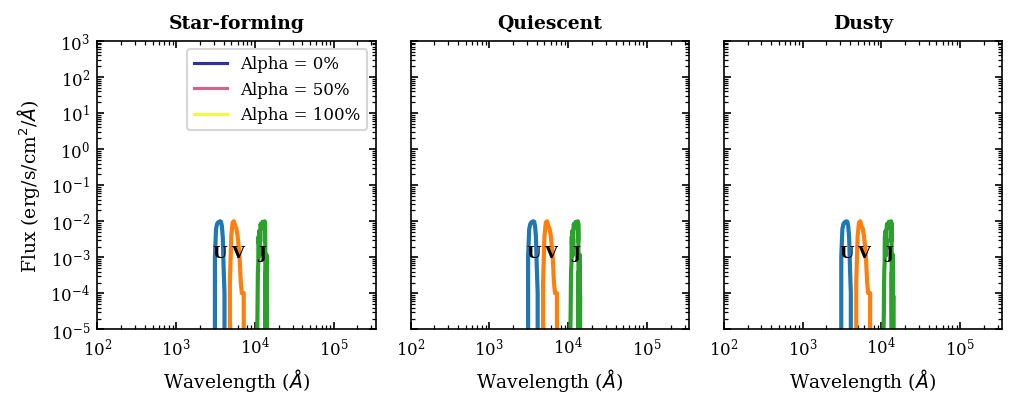

In [9]:
# Representative templates from Brown (GALSEDATLAS) set
# Star-forming: NGC_0337, Quiescent: NGC_4552, Dusty: IC_4553 (Arp 220)
rep_templates = {
    'Star-forming': 'NGC_0337',
    'Quiescent': 'NGC_4552',
    'Dusty': 'IC_4553'
}

comp_progression_data = {}

for pop_name, gal_name in rep_templates.items():
    if gal_name in brown_names:
        t_idx = brown_names.index(gal_name)
        gal_sed = brown_templates[t_idx]
        comp_progression_data[pop_name] = {}
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_type1, gal_sed, alpha)
            comp_progression_data[pop_name][alpha] = comp_sed

visualization.plot_composite_sed_progression(
    comp_progression_data, filters,
    show_title=True,
    orientation='horizontal',
    figsize=visualization.PASA_SED_WIDE,
    output_path=os.path.join(config.PROCESSED_DATA_DIR, 'CompositeSEDs_UVJ.pdf')
)
plt.show()

## 8. Observational ZFOURGE Composites (Fig 7, 8, Table 4)

This section confirms theoretical trends using observational ZFOURGE data by tracking how the average galaxy in each UVJ region evolves with increasing Type 1 AGN contribution.

C:\Users\uqmhooym\AppData\Local\Temp\ipykernel_16340\521216355.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])


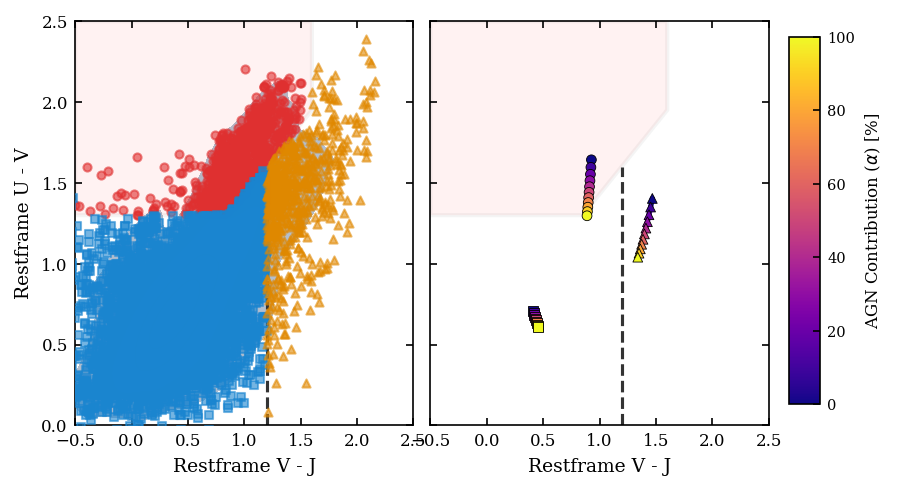

In [10]:
# Load the pre-generated observational composite data (calculated during Honours phase)
obs_csv_path = os.path.join('..\outputs', 'composite_seds', 'ZFOURGE_obsevational_composites_fluxesType1AGN.csv')
if os.path.exists(obs_csv_path):
    df_obs = pd.read_csv(obs_csv_path, index_col=0)

    # Re-classify Alpha=0 galaxies
    df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])

    # --- Left panel toggle --------------------------------------------------
    # 'density':     all sources shown (scatter coloured + marker-shaped by
    #                population, KDE density overlay) at their initial,
    #                pre-AGN (Alpha=0%) state. This is the default -- the
    #                right panel carries the AGN-contribution information
    #                instead (see below).
    # 'sensitivity': background heatmap = mean AGN-driven displacement
    #                magnitude per bin, with population membership as
    #                contour outlines rather than a solid scatter (kept here,
    #                unused by default, in case this reads better in print).
    LEFT_PANEL_MODE = 'density'
    AGN_SENSITIVITY_ALPHA = 100  # reference alpha (%) used for the displacement heatmap (sensitivity mode only)

    # Shared population styling: colour = population, marker shape = population
    # (o = Quiescent, s = Star-forming, ^ = Dusty) so both panels use the same
    # visual key. No in-panel legends -- the mapping is given in the caption.
    pop_names = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    scatter_colors = ('#E03030', '#1A85D0', '#E08800')
    markers = {0: 'o', 1: 's', 2: '^'}

    # Fig 7: UVJ left panel (initial state) + Average Region Tracks (right), combined double plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=visualization.PASA_WIDE, sharey=True)

    uv_0 = df_obs['U_0'] - df_obs['V_0']
    vj_0 = df_obs['V_0'] - df_obs['J_0']

    if LEFT_PANEL_MODE == 'density':
        # All sources: KDE density overlay + full scatter, coloured and
        # marker-shaped by population (matching the right panel's markers).
        sns.kdeplot(x=vj_0, y=uv_0, fill=True, cmap='cividis', levels=5, alpha=0.3, ax=ax1)
        for cid, name in pop_names.items():
            mask = df_obs['Classification'] == cid
            ax1.scatter(vj_0[mask], uv_0[mask], c=scatter_colors[cid], marker=markers[cid],
                        s=15, alpha=0.6, zorder=3)
        plot_uvj([], [], ax=ax1, title="")
        hb = None
    else:
        # Sensitivity heatmap: mean AGN-driven displacement magnitude per bin,
        # from the initial (Alpha=0%) position to AGN_SENSITIVITY_ALPHA%.
        uv_ref = df_obs[f'U_{AGN_SENSITIVITY_ALPHA}'] - df_obs[f'V_{AGN_SENSITIVITY_ALPHA}']
        vj_ref = df_obs[f'V_{AGN_SENSITIVITY_ALPHA}'] - df_obs[f'J_{AGN_SENSITIVITY_ALPHA}']
        displacement = np.sqrt((vj_ref - vj_0) ** 2 + (uv_ref - uv_0) ** 2)
        valid = vj_0.notna() & uv_0.notna() & displacement.notna()

        hb = ax1.hexbin(vj_0[valid], uv_0[valid], C=displacement[valid],
                         reduce_C_function=np.mean, gridsize=25, cmap='magma',
                         mincnt=5, zorder=1)

        # Population membership as unfilled contour outlines, not a solid
        # scatter: with ~11k points a full opaque scatter (as in 'density'
        # mode) forms a solid blob that completely hides the heatmap
        # underneath. Outlines keep the population regions legible while
        # letting the displacement heatmap show through.
        plot_uvj([], [], ax=ax1, title="")
        for cid, name in pop_names.items():
            mask = (df_obs['Classification'] == cid) & valid
            if mask.sum() < 10:
                continue
            sns.kdeplot(x=vj_0[mask], y=uv_0[mask], levels=3, color=scatter_colors[cid],
                        linewidths=1.5, ax=ax1, zorder=3)

    # Right panel: population tracks coloured by AGN contribution (alpha).
    # Colour is now used for alpha, so population identity is carried by
    # marker shape instead (matching the left panel's markers above).
    alpha_steps = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    alpha_cmap = plt.cm.plasma
    alpha_norm = plt.Normalize(vmin=0, vmax=100)

    plot_uvj([], [], ax=ax2, title="")

    for cid, name in pop_names.items():
        sub = df_obs[df_obs['Classification'] == cid]
        if len(sub) == 0: continue
        tvj = [sub[f'V_{a}'].mean() - sub[f'J_{a}'].mean() for a in alpha_steps]
        tuv = [sub[f'U_{a}'].mean() - sub[f'V_{a}'].mean() for a in alpha_steps]

        for i in range(len(tvj) - 1):
            ax2.plot(tvj[i:i + 2], tuv[i:i + 2], color=alpha_cmap(alpha_norm(alpha_steps[i])),
                      linewidth=2.5, solid_capstyle='round', zorder=2)
        ax2.scatter(tvj, tuv, c=[alpha_cmap(alpha_norm(a)) for a in alpha_steps],
                    marker=markers[cid], s=22, edgecolors='k', linewidths=0.4, zorder=4)

    ax2.set_ylabel('')

    # Colorbar(s): alpha (right panel, always shown) and, in 'sensitivity'
    # mode, the displacement heatmap (left panel) alongside it.
    if LEFT_PANEL_MODE == 'sensitivity':
        fig.subplots_adjust(wspace=0.05, right=0.78)
        disp_cbar_ax = fig.add_axes([0.80, 0.15, 0.03, 0.70])
        disp_cbar = fig.colorbar(hb, cax=disp_cbar_ax)
        disp_cbar.set_label(rf'Mean AGN displacement, $\alpha: 0\%\rightarrow{AGN_SENSITIVITY_ALPHA}\%$ (mag)', fontsize=7)
        disp_cbar.ax.tick_params(labelsize=6)
        alpha_cbar_ax = fig.add_axes([0.90, 0.15, 0.03, 0.70])
    else:
        fig.subplots_adjust(wspace=0.05, right=0.80)
        alpha_cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])

    sm = plt.cm.ScalarMappable(cmap=alpha_cmap, norm=alpha_norm)
    sm.set_array([])
    alpha_cbar = fig.colorbar(sm, cax=alpha_cbar_ax)
    alpha_cbar.set_label(r'AGN Contribution ($\alpha$) [%]', fontsize=8)
    alpha_cbar.ax.tick_params(labelsize=7)

    save_uvj_fig(fig, os.path.join(config.PROCESSED_DATA_DIR, 'ZFOURGE_UVJ_Density_RegionTracks_Combined.pdf'))
    plt.show()
else:
    print(f"Observational composite file not found at: {obs_csv_path}")

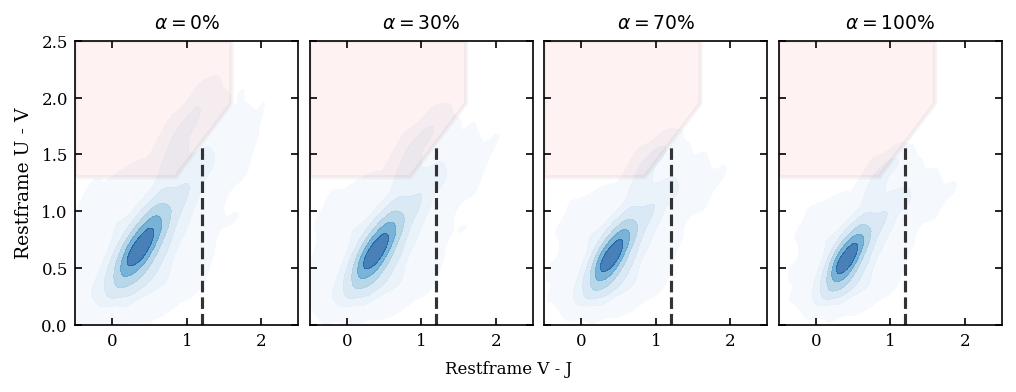

In [11]:
# --- Type 1 AGN UVJ Density Evolution (4-panel, ZFOURGE observational data) ---
alpha_cols   = [0, 30, 70, 100]
alpha_labels = [r'$\alpha=0\%$', r'$\alpha=30\%$', r'$\alpha=70\%$', r'$\alpha=100\%$']

fig, axes = plt.subplots(1, 4, figsize=(6.85, 2.5), sharex=True, sharey=True)

for ax, a, label in zip(axes, alpha_cols, alpha_labels):
    vj = df_obs[f'V_{a}'] - df_obs[f'J_{a}']
    uv = df_obs[f'U_{a}'] - df_obs[f'V_{a}']
    valid = vj.notna() & uv.notna()
    sns.kdeplot(x=vj[valid], y=uv[valid],
                fill=True, cmap='Blues', levels=7, thresh=0.02, alpha=0.75, ax=ax)
    plot_uvj([], [], ax=ax, title=label)
    for txt in ax.texts:
        txt.set_fontsize(6.5)
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[0].set_ylabel('Restframe U - V')
fig.text(0.5, -0.01, 'Restframe V - J', ha='center', fontsize=8)

plt.tight_layout()
fig.subplots_adjust(wspace=0.05)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

save_uvj_fig(fig, os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_Type1_Density_Evolution.pdf'))
plt.show()

## Export: Paper-Required Figures

Copies the subset of plots referenced by `Context/AGNPaper/paper.tex` into `outputs/PaperFigures/`, so that folder always reflects exactly what the paper needs (see `config.PAPER_FIGURE_MANIFEST`).

In [12]:
# Export the subset of plots required by Context/AGNPaper/paper.tex into
# outputs/PaperFigures/, and - if the gitignored Overleaf checkout is present
# locally - straight into its Images/TheoreticalModelPlots/ folder too, so
# the paper never silently references a stale/missing figure.
# (see config.PAPER_FIGURE_MANIFEST for the full list)
import shutil

os.makedirs(config.PAPER_FIGURES_DIR, exist_ok=True)
overleaf_present = os.path.isdir(config.AGNPAPER_DIR)
if overleaf_present:
    os.makedirs(config.PAPER_OVERLEAF_IMAGES_DIR, exist_ok=True)

copied, missing = [], []
for paper_filename, rel_source in config.PAPER_FIGURE_MANIFEST.items():
    src_path = os.path.join(config.PROCESSED_DATA_DIR, rel_source)
    dst_path = os.path.join(config.PAPER_FIGURES_DIR, paper_filename)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        if overleaf_present:
            shutil.copy2(src_path, os.path.join(config.PAPER_OVERLEAF_IMAGES_DIR, paper_filename))
        copied.append(paper_filename)
    else:
        missing.append(paper_filename)

print(f"Paper figures exported to {config.PAPER_FIGURES_DIR}")
if overleaf_present:
    print(f"  also copied to {config.PAPER_OVERLEAF_IMAGES_DIR}")
print(f"  {len(copied)}/{len(config.PAPER_FIGURE_MANIFEST)} copied")
if missing:
    print("  Still missing (not yet generated by any notebook run):")
    for name in missing:
        print(f"    - {name}")
    print("  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb")
    print("  (both top to bottom) to generate every required source plot.")
else:
    print("  All paper-required figures present.")

Paper figures exported to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\PaperFigures
  also copied to C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\Context\AGNPaper\Images\TheoreticalModelPlots
  9/12 copied
  Still missing (not yet generated by any notebook run):
    - UVJ_CIGALE_allhosts_fracAGN_colored_combined.pdf
    - UVJ_CIGALE_allhosts_fracAGN_colored_redshift_bins.pdf
    - Paper_UVJ_Contamination_Bias_Summary.pdf
  Run Paper_Results_Master.ipynb and Model_Validation_via_IRAC.ipynb
  (both top to bottom) to generate every required source plot.
